# Performance of Foster's CIR solver vs the Drift-implicit Euler scheme applied to the CIR process

We compare the performance of the two solvers on two examples of the CIR process, an easier one and a stiffer one. We also compare adaptive step size control with a fixed step size.

## Summary of results
Medium-volatility CIR (a=1, b=1, sigma=1.5):
- FosterCIR non-adaptive: 0.7824
- FosterCIR adaptive: 1.8225
- DriftImplicitEuler non-adaptive: 0.8618
- DriftImplicitEuler adaptive: 1.0269

High-volatility CIR (a=1, b=1, sigma=2.2):
- FosterCIR non-adaptive: 0.3944
- FosterCIR adaptive: 0.8092
- DriftImplicitEuler non-adaptive: 0.4642
- DriftImplicitEuler adaptive: 0.8618

In [1]:
from typing import Optional

from diffrax._custom_types import RealScalarLike


%env JAX_PLATFORM_NAME=cuda

from test.helpers import get_cir, path_l2_dist, SDE, sde_solver_strong_order

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import pandas as pd
from diffrax import (
    diffeqsolve,
    DriftImplicitEulerCIR as DIE,
    FosterCIR,
    PIDController,
    SaveAt,
)
from diffrax._step_size_controller.cir_adaptive import CIRController
from jax import config


config.update("jax_enable_x64", True)
jnp.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", "{:.3}".format)


def batch_sde_solve(keys, sde: SDE, dt0, solver, levy_area, _controller):
    _saveat = SaveAt(ts=[sde.t1])
    if hasattr(_controller, "dtmin"):
        bm_tol = 0.6 * jnp.minimum(dt0, _controller.dtmin)
    else:
        bm_tol = 0.6 * dt0

    @jax.jit
    @jax.vmap
    def single_sol(key):
        path = sde.get_bm(key, levy_area=levy_area, use_tree=True, tol=bm_tol)
        terms = sde.get_terms(path)

        sol = diffeqsolve(
            terms,
            solver,
            sde.t0,
            sde.t1,
            dt0=dt0,
            y0=sde.y0,
            args=sde.args,
            max_steps=2**17,
            stepsize_controller=_controller,
        )
        return sol.ys, sol.stats["num_accepted_steps"]

    return single_sol(keys)


def cir_strong_order(
    _keys,
    sde: SDE,
    solver,
    tol_precise,
    tols,
    _controller=CIRController,
):
    levy_area = "space-time"

    def cont(tol):
        if _controller == PIDController:
            return PIDController(
                pcoeff=0.1, icoeff=0.4, rtol=tol, atol=(tol / 128), dtmin=(tol / 128)
            )
        else:
            return _controller(
                ctol=tol,
                dtmin=jnp.maximum((tol / 128.0), 2**-17),
                dtmax=1.0,  # jnp.minimum(1.0, tol * 8.0)
            )

    correct_sols, _ = batch_sde_solve(
        _keys,
        sde,
        tol_precise,
        solver,
        levy_area=levy_area,
        _controller=cont(tol_precise),
        # _controller=ConstantStepSize()
    )

    @jax.jit
    @jax.vmap
    def get_single_err(tol):
        sols, step_counts = batch_sde_solve(
            _keys, sde, 1.0, solver, levy_area, cont(tol)
        )
        return path_l2_dist(sols, correct_sols), jnp.average(step_counts)

    errs, avg_steps = get_single_err(tols)
    order, _ = jnp.polyfit(jnp.log(1 / avg_steps), jnp.log(errs), 1)
    return tols, errs, avg_steps, order


# Plotting
def draw_order(hs, errs):
    plt.plot(1 / hs, errs)
    plt.yscale("log")
    plt.xscale("log")
    pretty_hs = ["{0:0.4f}".format(h) for h in hs]
    plt.xticks(ticks=1 / hs, labels=pretty_hs)
    plt.ylabel("RMS error")
    plt.xlabel("step size")
    plt.show()
    slope, intercept = jnp.polyfit(jnp.log(hs), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4}, intercept: {intercept:.4}")


def draw_adaptive_order(errs, steps):
    plt.plot(steps, errs)
    plt.yscale("log")
    plt.xscale("log")
    pretty_steps = [int(step) for step in steps]
    plt.xticks(ticks=pretty_steps, labels=pretty_steps)
    plt.ylabel("RMS error")
    plt.xlabel("number of steps")
    plt.show()
    slope, intercept = jnp.polyfit(jnp.log(4.0 / steps), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4}, intercept: {intercept:.4}")


def plot_sol_general(sol):
    plt.plot(sol.ts, sol.ys)
    plt.show()


def print_stats(
    errs: jnp.ndarray,
    time_diff: RealScalarLike,
    _tols: Optional[jnp.ndarray],
    _hs: Optional[jnp.ndarray] = None,
    num_steps: Optional[jnp.ndarray] = None,
):
    if _hs is not None:
        num_steps = time_diff / _hs
    elif num_steps is not None:
        _hs = time_diff / num_steps
    else:
        raise ValueError("Either hs or num_steps must be provided")
    column_names = ["hs", "num_steps", "errs"]
    columns = [_hs, num_steps, errs]
    if _tols is not None:
        tols_pow_hs = jnp.power(_tols, 2 / 3) / _hs
        columns.extend([_tols, _tols / errs, _tols / _hs, tols_pow_hs])
        column_names.extend(["tols", "tols/errs", "tols/hs", "tols^(2/3)/hs"])
    _table = jnp.stack(columns, axis=1)
    # Now use pandas to nicely print the table with the headers
    table = pd.DataFrame(_table, columns=column_names)
    print(table)


dtype = jnp.float64
num_samples = 1000
bm_key = jr.PRNGKey(2)
keys = jr.split(jr.PRNGKey(5678), num=num_samples)


def hs(n):
    return jnp.power(2.0, jnp.arange(-1, -n, -1, dtype=dtype))


def ctols(n):
    return jnp.power(2.0, jnp.arange(min(-1, 10 - n), -n, -1, dtype=dtype))


def get_dtype(x):
    if type(x) in [int, float, str]:
        return type(x)
    else:
        return jnp.dtype(x)


t0, t1 = 0.0, 16.0
t_short = 4.0
t_long = 32.0
saveat = SaveAt(steps=True)
dt0 = 1 / 8

args = (1.0, 1.0, 1.5)
print(f"tilde_b: {args[1] - (args[2]**2)/(4.0 * args[0])}")
cir = get_cir(t0, t1, args, dtype=dtype)
terms_cir = cir.get_terms(
    cir.get_bm(bm_key, levy_area="space-time", use_tree=True, tol=2**-12)
)
cir_short = get_cir(t0, t_short, args, dtype=dtype)
args_hard = (1.0, 1.0, 2.2)
cir_hard = get_cir(t0, t_short, args_hard, dtype=dtype)
terms_cir_hard = cir_hard.get_terms(
    cir_hard.get_bm(bm_key, levy_area="space-time", use_tree=True, tol=2**-14)
)
print(f"tilde_b_hard: {args_hard[1] - (args_hard[2]**2)/(4.0 * args_hard[0])}")

env: JAX_PLATFORM_NAME=cuda
tilde_b: 0.4375
tilde_b_hard: -0.2100000000000002


## Easy problem with medium volatility and positive tilde_b
a=1, b=1, sigma=1.5

Easy Foster non-adaptive


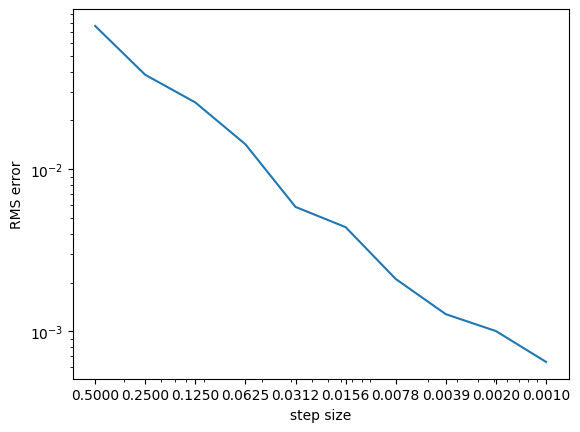

Order of convergence: 0.7824, intercept: -2.156
        hs  num_steps     errs
0      0.5        8.0   0.0765
1     0.25       16.0   0.0382
2    0.125       32.0   0.0258
3   0.0625       64.0   0.0142
4   0.0312   1.28e+02  0.00585
5   0.0156   2.56e+02  0.00439
6  0.00781   5.12e+02   0.0021
7  0.00391   1.02e+03  0.00128
8  0.00195   2.05e+03    0.001
9 0.000977    4.1e+03 0.000648


In [2]:
print("Easy Foster non-adaptive")
_, fos_errs, _ = sde_solver_strong_order(
    keys, cir_short, FosterCIR(), FosterCIR(), 2**-12, dts=hs(11)
)
draw_order(hs(11), fos_errs)
print_stats(fos_errs, 4.0, None, hs(11))

print("Easy Foster with CIRController")
_, fos_adap_errs, fos_adap_steps, _ = cir_strong_order(
    keys, cir_short, FosterCIR(), 2**-10, ctols(9), _controller=CIRController
)
draw_adaptive_order(fos_adap_errs, fos_adap_steps)
print_stats(fos_adap_errs, 4.0, ctols(9), num_steps=fos_adap_steps)

print("Easy DIE non-adaptive")
_, die_errs, _ = sde_solver_strong_order(
    keys, cir_short, DIE(), DIE(), 2**-12, dts=hs(11)
)
draw_order(hs(11), die_errs)
print_stats(die_errs, 4.0, None, hs(11))

print("Easy DIE with CIRController")
_, die_adap_errs, die_adap_steps, _ = cir_strong_order(
    keys, cir_short, DIE(), 2**-10, ctols(9), _controller=CIRController
)
draw_adaptive_order(die_adap_errs, die_adap_steps)
print_stats(die_adap_errs, 4.0, ctols(9), num_steps=die_adap_steps)

In [ ]:
# Plot the above 4 experiments together
plt.figure(dpi=300)
plt.plot(4.0 / hs(11), fos_errs, label="HOS non-adaptive")
plt.plot(fos_adap_steps, fos_adap_errs, label="HOS adaptive")
plt.plot(4.0 / hs(11), die_errs, label="DIE non-adaptive")
plt.plot(die_adap_steps, die_adap_errs, label="DIE adaptive")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.ylabel("RMS error")
plt.xlabel("average number of steps")
# Add the slope of the lines to the plot
slope_fos, intercept_fos = jnp.polyfit(jnp.log(4.0 * hs(11)), jnp.log(fos_errs), 1)
slope_die, intercept_die = jnp.polyfit(jnp.log(4.0 * hs(11)), jnp.log(die_errs), 1)
slope_fos_adap, intercept_fos_adap = jnp.polyfit(
    jnp.log(1 / fos_adap_steps), jnp.log(fos_adap_errs), 1
)
slope_die_adap, intercept_die_adap = jnp.polyfit(
    jnp.log(1 / die_adap_steps), jnp.log(die_adap_errs), 1
)
plt.text(
    0.05,
    0.1,
    "Orders of convergence:\n"
    f"HOS non-adaptive {slope_fos:.4}\n"
    f"HOS adaptive {slope_fos_adap:.4}\n"
    f"DIE non-adaptive {slope_die:.4}\n"
    f"DIE adaptive {slope_die_adap:.4}",
    transform=plt.gca().transAxes,
)

plt.show()

## Hard problem with high volatility and negative tilde_b
a=1, b=1, sigma=2.2

In [ ]:
print("Hard-CIR Foster non-adaptive")
_, fos_hard_errs, _ = sde_solver_strong_order(
    keys, cir_hard, FosterCIR(), FosterCIR(), 2**-12, dts=hs(11)
)
draw_order(hs(11), fos_hard_errs)
print_stats(fos_hard_errs, 4.0, None, hs(11))

print("Hard-CIR Foster with CIRController")
_, fos_hard_adap_errs, fos_hard_adap_steps, _ = cir_strong_order(
    keys, cir_hard, FosterCIR(), 2**-10, ctols(9), _controller=CIRController
)
draw_adaptive_order(fos_hard_adap_errs, fos_hard_adap_steps)
print_stats(fos_hard_adap_errs, 4.0, ctols(9), num_steps=fos_hard_adap_steps)

print("Hard-CIR DIE non-adaptive")
_, die_hard_errs, _ = sde_solver_strong_order(
    keys, cir_hard, DIE(), DIE(), 2**-12, dts=hs(11)
)
draw_order(hs(11), die_hard_errs)
print_stats(die_hard_errs, 4.0, None, hs(11))

print("Hard-CIR DIE with CIRController")
_, die_hard_adap_errs, die_hard_adap_steps, _ = cir_strong_order(
    keys, cir_hard, DIE(), 2**-10, ctols(9), _controller=CIRController
)
draw_adaptive_order(die_hard_adap_errs, die_hard_adap_steps)
print_stats(die_hard_adap_errs, 4.0, ctols(9), num_steps=die_hard_adap_steps)

In [ ]:
# Generate the same plot as above, but for the hard problem
plt.figure(dpi=300)
plt.plot(4.0 / hs(11), fos_hard_errs, label="HOS non-adaptive")
plt.plot(fos_hard_adap_steps, fos_hard_adap_errs, label="HOS adaptive")
plt.plot(4.0 / hs(11), die_hard_errs, label="DIE non-adaptive")
plt.plot(die_hard_adap_steps, die_hard_adap_errs, label="DIE adaptive")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.ylabel("RMS error")
plt.xlabel("average number of steps")
# Add the slope of the lines to the plot
slope_fos, _ = jnp.polyfit(jnp.log(4.0 * hs(11)), jnp.log(fos_hard_errs), 1)
slope_die, _ = jnp.polyfit(jnp.log(4.0 * hs(11)), jnp.log(die_hard_errs), 1)
slope_fos_adap, _ = jnp.polyfit(
    jnp.log(1 / fos_hard_adap_steps), jnp.log(fos_hard_adap_errs), 1
)
slope_die_adap, _ = jnp.polyfit(
    jnp.log(1 / die_hard_adap_steps), jnp.log(die_hard_adap_errs), 1
)
plt.text(
    0.05,
    0.1,
    "Orders of convergence:\n"
    f"HOS non-adaptive {slope_fos:.4}\n"
    f"HOS adaptive {slope_fos_adap:.4}\n"
    f"DIE non-adaptive {slope_die:.4}\n"
    f"DIE adaptive {slope_die_adap:.4}",
    transform=plt.gca().transAxes,
)

In [ ]:
print("DIE non-adaptive sample path")
solDIE = diffeqsolve(terms_cir, DIE(), t0, t1, dt0, cir.y0, cir.args, saveat=saveat)
plot_sol_general(solDIE)

print("DIE adaptive sample path")
controller = CIRController(ctol=2**-6, dtmin=2**-12, dtmax=1)
solDIE_pid = diffeqsolve(
    terms_cir,
    DIE(),
    t0,
    t1,
    1.0,
    cir.y0,
    cir.args,
    saveat=saveat,
    stepsize_controller=controller,
    max_steps=2**15,
)
plot_sol_general(solDIE_pid)
print(f'num steps: {solDIE_pid.stats["num_accepted_steps"]}')

In [ ]:
print("Foster (hard) adaptive sample path")
controller = CIRController(ctol=2**-6, dtmin=2**-12, dtmax=1)
solCIR_cont = diffeqsolve(
    terms_cir_hard,
    FosterCIR(),
    t0,
    t_short,
    1.0,
    cir.y0,
    cir.args,
    saveat=saveat,
    stepsize_controller=controller,
    max_steps=2**15,
)
plot_sol_general(solCIR_cont)
print(f'num steps: {solCIR_cont.stats["num_accepted_steps"]}')

print("Foster non-adaptive sample path")
solCIR = diffeqsolve(
    terms_cir, FosterCIR(1.0), t0, t1, dt0, cir.y0, cir.args, saveat=saveat
)
plot_sol_general(solCIR)

print("Foster adaptive sample path")
controller = CIRController(ctol=2**-6, dtmin=2**-12, dtmax=1)
solCIR_cont = diffeqsolve(
    terms_cir,
    FosterCIR(1.0),
    t0,
    t1,
    1.0,
    cir.y0,
    cir.args,
    saveat=saveat,
    stepsize_controller=controller,
    max_steps=2**15,
)
plot_sol_general(solCIR_cont)
print(f'num steps: {solCIR_cont.stats["num_accepted_steps"]}')

Easy Foster with CIRController


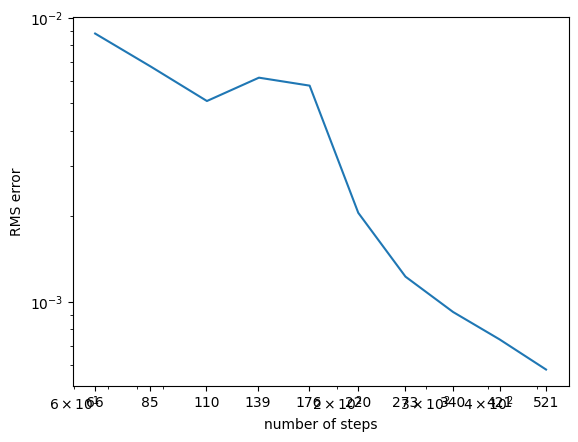

Order of convergence: 1.435, intercept: -0.426
       hs  num_steps     errs     tols  tols/errs  tols/hs  tols^(2/3)/hs
0  0.0605       66.1  0.00879 0.000122     0.0139  0.00202         0.0406
1  0.0469       85.4  0.00671  6.1e-05    0.00909   0.0013         0.0331
2  0.0363    1.1e+02  0.00509 3.05e-05      0.006 0.000841         0.0269
3  0.0286    1.4e+02  0.00615 1.53e-05    0.00248 0.000534         0.0215
4  0.0227   1.76e+02  0.00576 7.63e-06    0.00132 0.000337         0.0171
5  0.0181    2.2e+02  0.00206 3.81e-06    0.00185  0.00021         0.0135
6  0.0146   2.74e+02  0.00123 1.91e-06    0.00156 0.000131         0.0105
7  0.0117    3.4e+02 0.000921 9.54e-07    0.00104 8.12e-05        0.00825
8  0.0095   4.21e+02 0.000738 4.77e-07   0.000646 5.02e-05        0.00642
9 0.00768   5.21e+02 0.000578 2.38e-07   0.000413 3.11e-05        0.00501


In [5]:
from diffrax._step_size_controller.sde_adaptive import SDEController


# Adaptive convergence with the non-adaptive solution as reference
# Showing that indeed we converge to the correct solution
print("Easy Foster with CIRController")
_, fos_adap_errs2, fos_adap_steps2, _ = cir_strong_order(
    keys,
    cir_short,
    FosterCIR(half_stepping=True),
    2**-24,
    ctols(23),
    _controller=SDEController,
)
draw_adaptive_order(fos_adap_errs2, fos_adap_steps2)
print_stats(fos_adap_errs2, 4.0, ctols(23), num_steps=fos_adap_steps2)
#
# print("Hard-CIR Foster with CIRController")
# _, fos_hard_adap_errs2, fos_hard_adap_steps2, _ = cir_strong_order(
#     keys, cir_hard, FosterCIR(half_stepping=True),
#     2**-12, ctols(11), _controller=SDEController
# )
# draw_adaptive_order(fos_hard_adap_errs2, fos_hard_adap_steps2)
# print_stats(fos_hard_adap_errs2, 4.0, ctols(11), num_steps=fos_hard_adap_steps2)